In [16]:
import pandas as pd
import plotnine as pn
import numpy as np
from scipy.stats import beta
from itables import init_notebook_mode
import polars as pl
import os
init_notebook_mode(all_interactive=True)

In [17]:
import sys
sys.path.append("/home/a379i/Scripts")   # path to folder containing the python file

In [18]:
from utils.load_gtf_cgc_dresden import *
from ProteinExpression.load_pr_data import *

In [19]:
sa = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/sample_data/master_drop_sample_annotation_sizeFactorFiltered_0.1.tsv", sep="\t")

In [20]:
pr_output_name = "cov_gaussian_gs_lr_0_001_epoc2000_noInitPCA"

In [21]:
# pr_res_all = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/output_" + pr_output_name + "/pr_variants.csv")
pr_res_all = pd.read_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/output_" + pr_output_name + "/pr_variants_predisppadjust_cnv.parquet")

In [22]:
pr_res_all.columns

Index(['sampleID', 'proteinID', 'PROTEIN_LOG2INT', 'PROTEIN_EXPECTED_LOG2INT',
       'PROTEIN_INT', 'zScore', 'pValue', 'padjust', 'PROTEIN_LOG2FC',
       'PROTEIN_FC', 'aberrant', 'pvalDistribution', 'seqnames', 'start',
       'end', 'strand', 'gene_id', 'gene_name', 'gene_type', 'gene_status',
       'gene_name_orig', 'geneID_short', 'geneID', 'Gene', 'IMPACT_snv',
       'Consequence_snv', 'ANNOTATION_control_snv', 'promoterAI_snv',
       'Location', 'Allele', 'ref', '#Uploaded_variation_snv', 'Gene_indel',
       'IMPACT_indel', 'Consequence_indel', 'ANNOTATION_control_indel',
       'Location_indel', 'Allele_indel', 'variant_type', 'IMPACT',
       'Outlier status', 'padjust_predisp', 'padjust_predisp_extended', 'CNV'],
      dtype='object')

In [23]:
pr_res_all = pd.merge(pr_res_all, dresden_dt_cgc[["gene_name", "gene_type", "geneID_short", "ROLE_IN_CANCER", "predisposition_gene"]], right_on="geneID_short", left_on="geneID", how="left")
pr_res_all = pd.merge(pr_res_all, sa, left_on="sampleID", right_on="pid")

In [24]:
pr_res_all = pr_res_all.sort_values("pValue")
pr_res_all = pr_res_all.drop_duplicates(subset=["proteinID", "sampleID"])

In [25]:
pr_res_all["Method"] = "PROTRIDER"
print(pr_res_all.shape)

(7426754, 93)


In [26]:
pr_output_name_2 = "zScore_gt3"
pr_res_all_zScores = pd.read_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/output_" + pr_output_name_2 + "/pr_variants_predisppadjust_cnv.parquet")
pr_res_all_zScores = pd.merge(pr_res_all_zScores, dresden_dt_cgc[["gene_name", "gene_type", "geneID_short", "ROLE_IN_CANCER", "predisposition_gene"]], right_on="geneID_short", left_on="geneID", how="left")
pr_res_all_zScores = pd.merge(pr_res_all_zScores, sa, left_on="sampleID", right_on="pid")

In [27]:
pr_res_all_zScores = pr_res_all_zScores.drop_duplicates(subset=["proteinID", "sampleID"])
pr_res_all_zScores["Method"] = "sf-normalized zScores"

In [28]:
pr_res_all_zScores["CNV"].value_counts()

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [29]:
pr_res_all["gene_sample"] = pr_res_all["proteinID"] + "_" + pr_res_all["sampleID"]
pr_res_all_zScores["gene_sample"] = pr_res_all_zScores["proteinID"] + "_" + pr_res_all_zScores["sampleID"]

a = set(pr_res_all_zScores["gene_sample"]).intersection(set(pr_res_all["gene_sample"]))

In [31]:
merged = pr_res_all_zScores[["gene_sample", "CNV"]].merge(pr_res_all[["gene_sample", "CNV"]], on="gene_sample")
merged

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [86]:
def calculate_proportions(df, expression_col="CNV"):
    # Work on a copy to prevent SettingWithCopyWarning and index fragmentation
    df = df.copy()
    
    for expression_direction in ["overexpression", "underexpression"]:
    # for expression_direction in ["underexpression"]:
        vus_col = f"VUS_{expression_direction}_{expression_col}"
        df[vus_col] = False

        # 1. Define VUS based on CNV/VEP type
        if expression_col == "CNV":
            if expression_direction == "underexpression":
                if (df["Method"] == "sf-normalized zScores").any():
                    df = df.sort_values("zScore", ascending=True) 
                df.loc[df[expression_col].str.contains("DEL", na=False), vus_col] = True
            else:
                if (df["Method"] == "sf-normalized zScores").any():
                    df = df.sort_values("zScore", ascending=False)
                df.loc[df[expression_col].str.contains("AMP|DUP", na=False), vus_col] = True
                
        elif expression_col == "VEP":
            df.loc[(df["IMPACT"] == "HIGH"), vus_col] = True
            
        elif expression_col == "CNV_VEP":
            # Combined logic: either high impact VEP or relevant CNV
            if expression_direction == "underexpression":
                if (df["Method"] == "sf-normalized zScores").any():
                    df = df.sort_values("zScore", ascending=True)
                df.loc[df["CNV"].str.contains("DEL", na=False) | (df["IMPACT"] == "HIGH"), vus_col] = True
            else:
                if (df["Method"] == "sf-normalized zScores").any():
                    df = df.sort_values("zScore", ascending=False)
                df.loc[df["CNV"].str.contains("AMP|DUP", na=False) | (df["IMPACT"] == "HIGH"), vus_col] = True
        
        else: # Fallback for other custom expression_cols
            if expression_direction == "underexpression":
                if (df["Method"] == "sf-normalized zScores").any():
                    df = df.sort_values("zScore", ascending=True)   
                df.loc[df[expression_col].str.contains("DEL", na=False), vus_col] = True
            else:
                if (df["Method"] == "sf-normalized zScores").any():
                    df = df.sort_values("zScore", ascending=False)
                df.loc[df[expression_col].str.contains("AMP|DUP", na=False), vus_col] = True
                df.loc[(df["IMPACT"] == "HIGH"), vus_col] = True

        # 2. Subset based on zScore direction for proportion calculation
        if expression_direction == "underexpression":
            mask = df['zScore'] < 0
        else:
            mask = df['zScore'] > 0
            
        # Create a temporary subset to calculate running statistics
        # This ensures we don't have indexing conflicts with the main DF
        subset = df.loc[mask].copy()
        
        if len(subset) > 0:
            # Calculate ranks and cumulative counts
            u_rank = np.arange(1, len(subset) + 1)
            u_vus = (subset[vus_col] == True).to_numpy()
            u_x = np.cumsum(u_vus)
            
            # Vectorized Clopper–Pearson interval calculation
            alpha = 0.05
            # beta.ppf handles the statistics for the CI
            ci_min = beta.ppf(alpha/2, u_x, u_rank - u_x + 1)
            ci_max = beta.ppf(1 - alpha/2, u_x + 1, u_rank - u_x)

            # Map the calculated values back to the original 'df' using the mask
            df.loc[mask, f"{expression_direction}_rank"] = u_rank
            df.loc[mask, f"{expression_direction}_proportions_{expression_col}"] = u_x / u_rank
            df.loc[mask, f"{expression_direction}_ci_min_{expression_col}"] = ci_min
            df.loc[mask, f"{expression_direction}_ci_max_{expression_col}"] = ci_max

    return df

In [88]:
import numpy as np

def get_auc_metrics(df, expression_direction="underexpression", log_scale=True):
    """
    Calculates Area Under the Curve (AUC) and Mean Proportion for variant enrichment.
    
    If log_scale=True, the AUC represents the area as seen on a log-x plot.
    The 'mean_proportion' represents the average height of the curve over that range.
    """
    # Filter for valid ranks and remove NaNs to prevent calculation errors
    mask = (df[f"{expression_direction}_rank"] > 100) & \
           (df[f"{expression_direction}_rank"].notna())
    
    subset = df[mask].sort_values(f"{expression_direction}_rank")
    
    if subset.empty:
        return {}

    # Define x-coordinates
    x_linear = subset[f"{expression_direction}_rank"].values
    x = np.log10(x_linear) if log_scale else x_linear
    
    # Calculate the span of the x-axis (width)
    x_range = x.max() - x.min()
    
    results = {}
    for variant_type in ["CNV", "VEP"]:
        y_col = f"{expression_direction}_proportions_{variant_type}"
        
        if y_col in subset.columns:
            y = subset[y_col].values
            
            # 1. Calculate Raw AUC (Trapezoidal Rule)
            area = np.trapz(y, x)
            
            # 2. Calculate Mean Proportion (Average Height)
            # This normalizes the area by the width of the plot
            mean_prop = area / x_range if x_range > 0 else 0
            
            results[variant_type] = {
                "raw_auc": area,
                "mean_proportion": mean_prop
            }
            
    return results


# # Usage:
protrider_auc_underexpression = get_auc_metrics(pr_res_all)

zscore_auc_underexpression = get_auc_metrics(pr_res_all_zScores)

protrider_auc_overexpression = get_auc_metrics(pr_res_all, expression_direction="overexpression")

zscore_auc_overexpression = get_auc_metrics(pr_res_all, expression_direction="overexpression")


In [89]:
def plot_variant_proportions(plot_data, auc_dict, plot_title = "OUTRIDER", expression_direction = "underexpression"):

    
    if expression_direction == "underexpression":
        direction_mask = plot_data["zScore"] < 0
        plot_data = plot_data[plot_data["zScore"] < 0]
        CNV_label = "Deletion CNV"
        
    else:
        direction_mask = plot_data["zScore"] > 0
        plot_data = plot_data[plot_data["zScore"] > 0]
        CNV_label = "AMP/DUP CNV"

    # Apply filtering for the plot range (same as in ggplot call)
    plot_subset = plot_data[
        direction_mask & 
        (plot_data[f"{expression_direction}_rank"] > 100) & 
        (plot_data[f"{expression_direction}_rank"] < 1e10)
    ].copy()

    # 2. Calculate Dynamic X and Y
    # Get the furthest point on the right
    max_x = plot_subset[f"{expression_direction}_rank"].max()
    
    # Find the absolute highest point in the plot (top of the CI ribbons)
    ci_cols = [f"{expression_direction}_ci_max_CNV", f"{expression_direction}_ci_max_VEP"]
    # We take the max of those columns, then add a 5% buffer of the total y-span
    actual_y_max = plot_subset[ci_cols].max().max()
    dynamic_y = actual_y_max + (actual_y_max * 0.05)
    
    cnv_text = f"{CNV_label} \n (AUC: {auc_dict['CNV']['mean_proportion']:.1%})"
    vep_text = f"VEP \n (AUC:{auc_dict['VEP']['mean_proportion']:.1%})"
    annotation_text = f"{cnv_text}\n{vep_text}"

    max_rank = plot_data[f"{expression_direction}_rank"].max()

    return (
        pn.ggplot(plot_data[
                                (plot_data[f"{expression_direction}_rank"] > 100) & 
                                (plot_data[f"{expression_direction}_rank"] < 1e10)])
            
            # --- Line 1 (Deletion) ---
            # We map 'color' to a string label. Plotnine sees this as a category.
            + pn.geom_line(pn.aes(x=f"{expression_direction}_rank", 
                                y=f"{expression_direction}_proportions_CNV", 
                                color=f"'{CNV_label}'")) 
            + pn.geom_ribbon(pn.aes(x=f"{expression_direction}_rank", 
                                    ymin=f"{expression_direction}_ci_min_CNV", ymax=f"{expression_direction}_ci_max_CNV", 
                                    fill=f"'{CNV_label}'"), 
                            alpha=0.2, outline_type='none')
            
            # --- Line 2 (VEP) ---
            + pn.geom_line(pn.aes(x=f"{expression_direction}_rank", 
                                y=f"{expression_direction}_proportions_VEP", 
                                color="'VEP HIGH impact'"))
            + pn.geom_ribbon(pn.aes(x=f"{expression_direction}_rank", 
                                    ymin=f"{expression_direction}_ci_min_VEP", ymax=f"{expression_direction}_ci_max_VEP", 
                                    fill="'VEP HIGH impact'"), 
                            alpha=0.2, outline_type='none')
            # --- Assigning Colors Manually ---
            # We use a dictionary to ensure 'Deletion CNV' is blue and 'VEP' is red
            + pn.scale_color_manual(name="Variant Type", 
                                    values={CNV_label: "blue", "VEP HIGH impact": "red"},
                                   labels={CNV_label: cnv_text, "VEP HIGH impact": vep_text})
            + pn.scale_fill_manual(name="Variant Type", 
                                values={CNV_label: "blue", "VEP HIGH impact": "red"},
                                  labels={CNV_label: cnv_text, "VEP HIGH impact": vep_text})
            
            + pn.scale_x_log10()
            + pn.annotation_logticks(sides="b")
            + pn.labs(
                y=f"Proportion of {expression_direction} outliers\nwith rare variants",
                x="Outlier rank cutoff",
                title = plot_title
            )
            + pn.theme_bw(base_size=12)
    )

In [90]:
pr_res_all = calculate_proportions(pr_res_all, expression_col="CNV")
pr_res_all = calculate_proportions(pr_res_all, expression_col="VEP")


In [91]:
print(pr_res_all.shape)

(7426754, 110)


In [ ]:
p = plot_variant_proportions(
    pr_res_all, protrider_auc_underexpression, plot_title="PTORDIER (across all genes)", expression_direction="underexpression")
p.save("/home/a379i/Scripts/ProteinExpression/proportions_all_genes_underexpression_outliers.png", width=6, height=4, dpi=300)

/tmp/ipykernel_2643077/1680499253.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6 x 4 in image.
/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /home/a379i/Scripts/ProteinExpression/proportions_all_genes_underexpression_outliers.png


/tmp/ipykernel_2643077/1680499253.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.


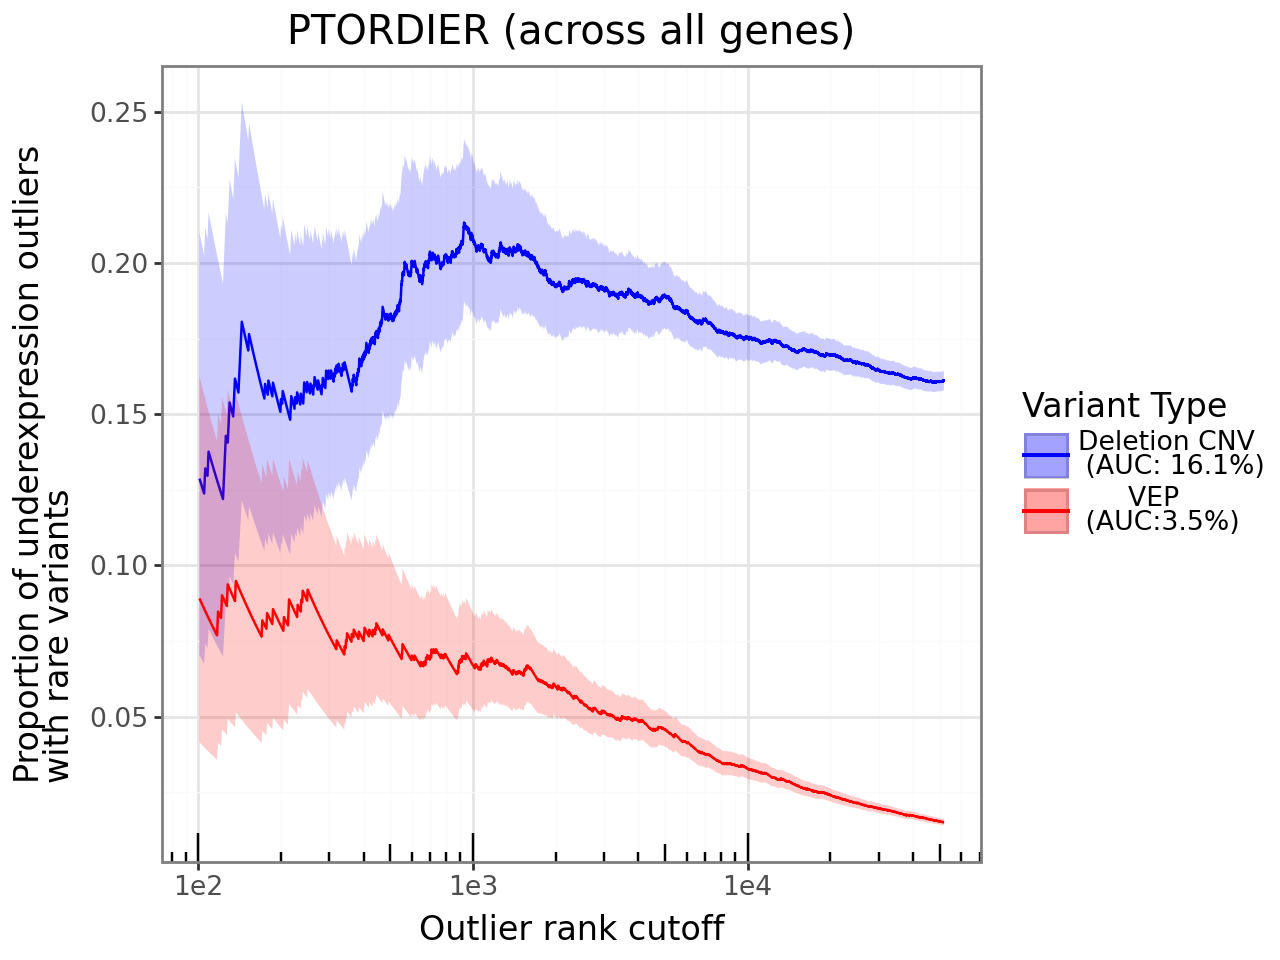

In [41]:
p = plot_variant_proportions(
    pr_res_all[:100000], protrider_auc_underexpression, plot_title="PTORDIER (across all genes)", expression_direction="underexpression")
p

In [10]:
pr_res_all_zScores = calculate_proportions(pr_res_all_zScores, "CNV")
pr_res_all_zScores = calculate_proportions(pr_res_all_zScores, "VEP")

In [ ]:
pr_res_all_zScores["CNV"].value_counts()

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [12]:
pr_res_all_zScores["sampleID"].value_counts()
# len(pr_res_all_zScores["sampleID"].unique())

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [12]:
# pr_res_all_zScores[pr_res_all_zScores["zScore"].notna()][:200]
pr_res_all_zScores.shape
pr_res_all_zScores[pr_res_all_zScores["zScore"] < 0].shape

(3531354, 109)

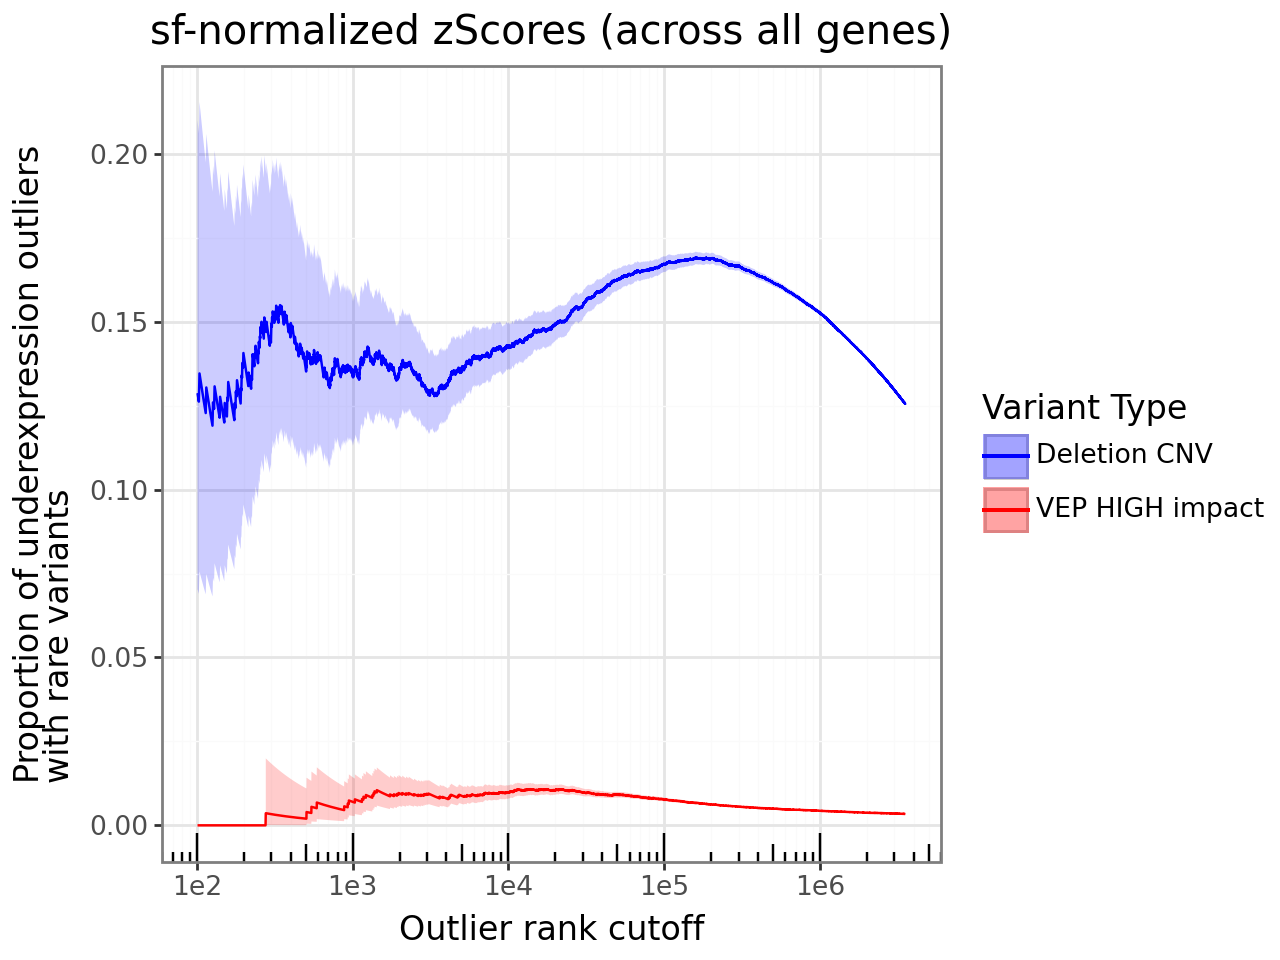

In [13]:
p2 = plot_variant_proportions(
    pr_res_all_zScores, plot_title="sf-normalized zScores (across all genes)", expression_direction="underexpression")
# p2.save("/home/a379i/Scripts/ProteinExpression/proportions_all_genes_underexpression_outliers_sf_normalized_zscores.png", width=6, height=4, dpi=300)
p2

In [ ]:
# overexpression
p3 = plot_variant_proportions(
    pr_res_all, plot_title="PROTRIDER (across all genes)", expression_direction="overexpression")
p3.save("/home/a379i/Scripts/ProteinExpression/proportions_all_genes_overexpression_outliers.png", width=6, height=4, dpi=300)

In [ ]:
# predispostions
py_or_res_predisp = pr_res_all[pr_res_all["padjust_predisp_extended"].notna()]
py_or_res_predisp = py_or_res_predisp.sort_values("padjust_predisp_extended")

In [ ]:
gene_zscore_predisp = pr_res_all_zScores[pr_res_all_zScores["proteinID"].isin(extended_dresden_list)]

In [ ]:
gene_zscore_predisp = calculate_proportions(gene_zscore_predisp, "CNV_VEP")
gene_zscore_predisp = calculate_proportions(gene_zscore_predisp, "CNV")
gene_zscore_predisp = calculate_proportions(gene_zscore_predisp, "VEP")

In [ ]:
py_or_res_predisp = calculate_proportions(py_or_res_predisp, "CNV")
py_or_res_predisp = calculate_proportions(py_or_res_predisp, "VEP")
py_or_res_predisp = calculate_proportions(py_or_res_predisp, "CNV_VEP")

In [ ]:
p4 = plot_variant_proportions(
    py_or_res_predisp, plot_title="OUTRIDER (only predispostion genes)", expression_direction="underexpression")
p4.save("/home/a379i/Scripts/ProteinExpression/proportions_predisposition_genes_underexpression_outliers.png", width=6, height=4, dpi=300)

In [ ]:
p5 = plot_variant_proportions(
    py_or_res_predisp, plot_title="OUTRIDER (only predisposition genes)", expression_direction="overexpression")
p5.save("/home/a379i/Scripts/ProteinExpression/proportions_predisposition_genes_overexpression_outliers.png", width=6, height=4, dpi=300)

zScores vs OUTRIDER: both CNV and VEP_HIGH

In [18]:
pr_res_all = calculate_proportions(pr_res_all, "CNV_VEP")
pr_res_all.drop_duplicates(subset=["proteinID", "sampleID"]).shape

# gene_zscore = calculate_proportions(pr_res_all_zScores, "CNV_VEP")

(7426754, 119)

In [30]:
len(pr_res_all), len(gene_zscore)

(7440201, 7426754)

(7426754, 119)

In [ ]:
plot_dt = pd.concat([pr_res_all, gene_zscore])

In [ ]:
for expression_direction in ["underexpression", "overexpression"]:

    if expression_direction == "underexpression":
            plot_data = plot_dt[plot_dt["zScore"] < 0]
            CNV_label = "Deletion CNV"
            CNV_label = "AMP/DUP CNV"
    else:
        plot_data = plot_dt[plot_dt["zScore"] > 0]


    p = ( pn.ggplot(plot_data[(plot_data[f"{expression_direction}_rank"] > 100) & 
                                    (plot_data[f"{expression_direction}_rank"] < 1e10)])
                
                # --- Line 1 (Deletion) ---
                # We map 'color' to a string label. Plotnine sees this as a category.
                + pn.geom_line(pn.aes(x=f"{expression_direction}_rank", 
                                    y=f"{expression_direction}_proportions_CNV_VEP", 
                                    color="Method")) 
                + pn.geom_ribbon(pn.aes(x=f"{expression_direction}_rank", 
                                        ymin=f"{expression_direction}_ci_min_CNV_VEP", ymax=f"{expression_direction}_ci_max_CNV_VEP", 
                                        fill="Method"), 
                                alpha=0.2, outline_type='none')
                
            
                + pn.scale_x_log10()
                + pn.annotation_logticks(sides="b")
                + pn.labs(
                    y=f"Proportion of {expression_direction} outliers\nwith variants (Rare SNV/indel and CNV)",
                    x="Outlier rank cutoff",
                    title="Across all genes"
                )
                + pn.theme_bw(base_size=12)
    )

    p.save(f"/home/a379i/Scripts/ProteinExpression/proportions_{expression_direction}_or_vs_zScore.png", width=6, height=4, dpi=300)